# Baseline aqueous-solubility model (Delaney ESOL)

This notebook documents the model behind the solubility estimate in BioEnhance Agent.

The point is **not** to build a state-of-the-art solubility predictor. It is to give the
LLM a calculated estimate with an honest error bar, so that the agent's solubility claim
comes from measured data rather than from a language model's recollection.

Run from the repository root: `jupyter lab notebooks/solubility_model.ipynb`

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from src.solubility_model import FEATURES, RANDOM_STATE, build_training_frame

Matplotlib is building the font cache; this may take a moment.


## 1. The data

ESOL (Delaney 2004) — 1128 compounds with **measured** log solubility in mol/L.

Descriptors are recomputed from SMILES with the same RDKit code path the app uses at
inference time, so training and prediction cannot silently diverge.

In [2]:
frame = build_training_frame()
print(f"{len(frame)} compounds featurised")
frame.describe().T[["mean", "std", "min", "max"]].round(2)

1128 compounds featurised


,mean,std,min,max
molecular_weight,203.94,102.74,16.04,780.95
clogp,2.45,1.85,-7.57,10.39
tpsa,34.87,35.38,0.00,268.68
h_bond_donors,0.70,1.09,0.00,11.00
h_bond_acceptors,2.07,2.11,0.00,16.00
rotatable_bonds,2.18,2.64,0.00,23.00
aromatic_rings,0.93,1.01,0.00,7.00
fraction_csp3,0.44,0.37,0.00,1.00
molar_refractivity,54.02,25.28,6.73,192.61
heavy_atoms,13.29,6.88,1.00,55.00


Pearson r (cLogP vs log S) = -0.828


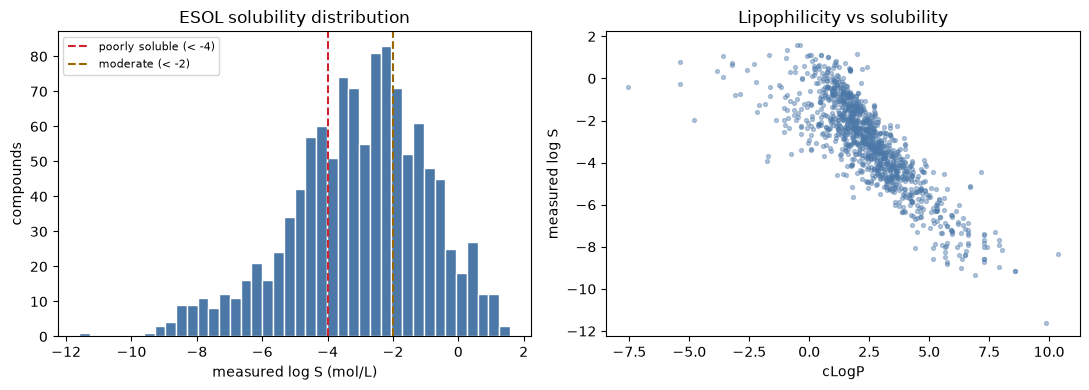

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(frame["log_s"], bins=40, color="#4c78a8", edgecolor="white")
axes[0].axvline(-4, color="#cf222e", ls="--", label="poorly soluble (< -4)")
axes[0].axvline(-2, color="#9a6700", ls="--", label="moderate (< -2)")
axes[0].set_xlabel("measured log S (mol/L)")
axes[0].set_ylabel("compounds")
axes[0].set_title("ESOL solubility distribution")
axes[0].legend(fontsize=8)

axes[1].scatter(frame["clogp"], frame["log_s"], s=8, alpha=0.4, color="#4c78a8")
axes[1].set_xlabel("cLogP")
axes[1].set_ylabel("measured log S")
axes[1].set_title("Lipophilicity vs solubility")
plt.tight_layout()

r = np.corrcoef(frame["clogp"], frame["log_s"])[0, 1]
print(f"Pearson r (cLogP vs log S) = {r:.3f}")

cLogP alone is strongly (negatively) correlated with solubility — the single most useful
descriptor here, and the reason it dominates feature importance below.

## 2. Baseline comparison

Compare a linear model against the random forest. If the forest cannot beat a linear fit,
the extra complexity is not earning its place.

In [4]:
X = frame[FEATURES].to_numpy()
y = frame["log_s"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

models = {
    "Linear regression": LinearRegression(),
    "Random forest": RandomForestRegressor(
        n_estimators=500, max_features=0.5, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

rows = []
preds = {}
for label, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    preds[label] = pred
    rows.append(
        {
            "model": label,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
        }
    )

pd.DataFrame(rows).round(3)

,model,RMSE,R2
0,Linear regression,1.025,0.778
1,Random forest,0.758,0.878


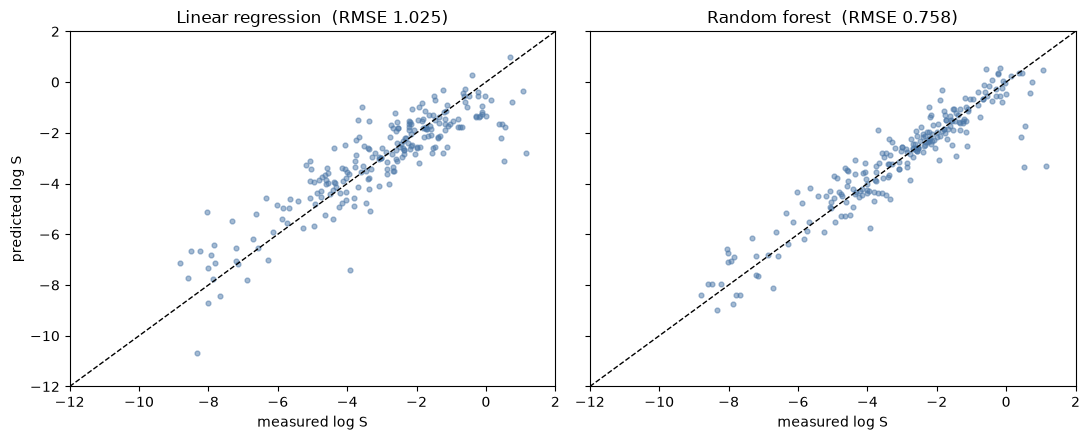

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (label, pred) in zip(axes, preds.items()):
    ax.scatter(y_test, pred, s=12, alpha=0.5, color="#4c78a8")
    lims = [-12, 2]
    ax.plot(lims, lims, "k--", lw=1)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.set_title(f"{label}  (RMSE {rmse:.3f})")
    ax.set_xlabel("measured log S")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
axes[0].set_ylabel("predicted log S")
plt.tight_layout()

## 3. Feature importance

clogp                  0.474
molar_refractivity     0.202
molecular_weight       0.099
tpsa                   0.062
heavy_atoms            0.058
h_bond_acceptors       0.044
fraction_csp3          0.015
aromatic_rings         0.013
rotatable_bonds        0.012
h_bond_donors          0.011
aromatic_proportion    0.010
dtype: float64

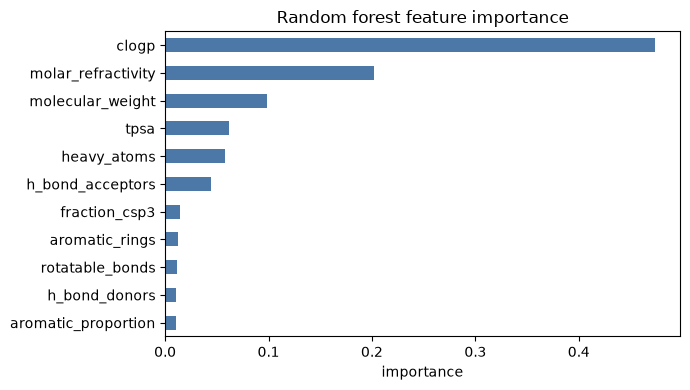

In [6]:
rf = models["Random forest"]
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

imp.plot.barh(figsize=(7, 4), color="#4c78a8")
plt.xlabel("importance")
plt.title("Random forest feature importance")
plt.tight_layout()
imp.sort_values(ascending=False).round(3)

## 4. Where the model is wrong, and why it matters

The largest errors are the honest part of this notebook. An RMSE of ~0.76 log units is
roughly a factor of six in solubility — enough to move a compound across a decision
boundary.

residual mean -0.037, std 0.757
|residual| > 1 log unit: 13.7% of test compounds


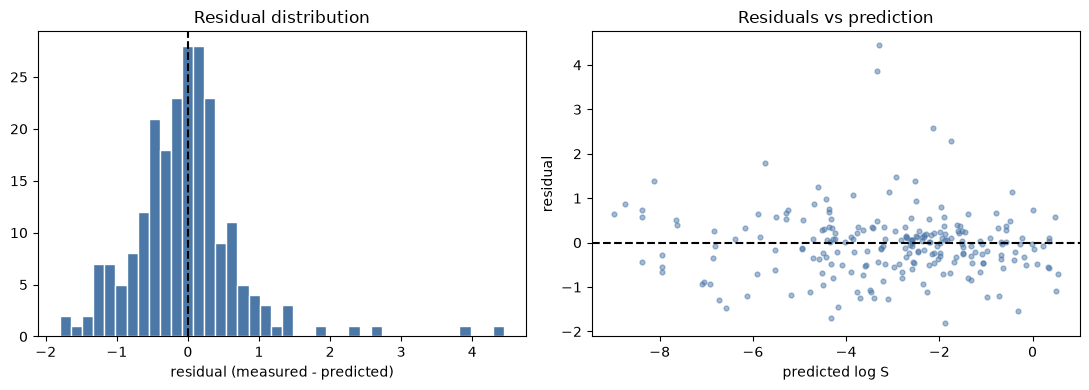

In [7]:
residuals = y_test - preds["Random forest"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(residuals, bins=40, color="#4c78a8", edgecolor="white")
axes[0].axvline(0, color="k", ls="--")
axes[0].set_xlabel("residual (measured - predicted)")
axes[0].set_title("Residual distribution")

axes[1].scatter(preds["Random forest"], residuals, s=12, alpha=0.5, color="#4c78a8")
axes[1].axhline(0, color="k", ls="--")
axes[1].set_xlabel("predicted log S")
axes[1].set_ylabel("residual")
axes[1].set_title("Residuals vs prediction")
plt.tight_layout()

print(f"residual mean {residuals.mean():.3f}, std {residuals.std():.3f}")
print(f"|residual| > 1 log unit: {(np.abs(residuals) > 1).mean():.1%} of test compounds")

## 5. The ionisation blind spot

The model has no concept of pKa or ionisation state. It predicts intrinsic
(neutral-species) solubility, so a strong base that exists as a soluble cation at
physiological pH is systematically underestimated.

**Metformin** is the clearest case, and it is why it fails as a negative control in the
evaluation. This is a limitation to report, not a threshold to tune away.

In [8]:
from src.descriptors import compute_descriptors
from src.solubility_model import get_predictor

predictor = get_predictor()

cases = {
    "metformin (strong base, freely soluble)": "CN(C)C(=N)N=C(N)N",
    "paracetamol (neutral, soluble)": "CC(=O)NC1=CC=C(C=C1)O",
    "itraconazole (neutral, insoluble)": "CCC(C)N1C(=O)N(C=N1)c1ccc(cc1)N1CCN(CC1)c1ccc(OCC2COC(Cn3cncn3)(O2)c2ccc(Cl)cc2Cl)cc1",
}

rows = []
for label, smi in cases.items():
    d = compute_descriptors(smi)
    s = predictor.predict(d)
    rows.append(
        {
            "compound": label,
            "cLogP": d.clogp,
            "pred log S": s.log_s,
            "+/- (ensemble)": s.log_s_std,
            "risk": s.risk.value,
            "outside training domain": bool(s.applicability_warning),
        }
    )

pd.DataFrame(rows).round(2)

,compound,cLogP,pred log S,+/- (ensemble),risk,outside training domain
0,"metformin (strong base, freely soluble)",-1.24,-2.02,0.95,moderate,False
1,"paracetamol (neutral, soluble)",1.35,-1.37,0.54,low,False
2,"itraconazole (neutral, insoluble)",5.58,-6.37,1.50,high,True


## 6. Conclusion

- The random forest reaches **RMSE ≈ 0.76 log units, R² ≈ 0.88** on a held-out split,
  which is in line with published ESOL baselines.
- cLogP dominates feature importance, which is chemically sensible.
- The model is used in the app **with** its RMSE, an ensemble spread and an
  applicability-domain check, so neither the LLM nor the user is invited to over-trust a
  point estimate.
- Its blind spots — ionisation and solid-state effects — are exactly the items the agent
  reports under `missing_information` on every run.